In [1]:

import re
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.special import kn, kve


import BOLEH as bl

In [2]:
MATRIZ_FILEM1 = "mat3M1NO.txt"
MATRIZ_FILEM2= "mat3M2NO.txt"
n=3

def leer_matrices(path):
    with open(path, 'r') as f:
        texto = f.read()

    secciones = re.split(r'#\s*', texto)
    secciones = [s.strip() for s in secciones if s.strip()]

    matrices = {}
    for sec in secciones:
        lineas = sec.splitlines()
        nombre = lineas[0].strip()
        contenido = "\n".join(lineas[1:]).strip()
        matrices[nombre] = eval(contenido, {"np": np})
    return matrices


data1 = leer_matrices(MATRIZ_FILEM1)
data2 =leer_matrices(MATRIZ_FILEM2)

yE1 = data1['yEo']
y1  = data1['yo']
M   = data1['M']

yE2 = data2['yEo']
y2  = data2['yo']
M   = data2['M']


geff=106.75
theta12=0.227
theta23=4.65e-2
theta13=4.11e-3
delta=1.139j

V23=np.array([[ 1, 0, 0],
 [0, np.cos(theta23), np.sin(theta23)],
 [0, -np.sin(theta23), np.cos(theta23)]], dtype=np.complex128)

V13=np.array([[np.cos(theta13) , 0, np.sin(theta13)*np.exp(-delta)],
 [0, 1, 0],
 [- np.sin(theta13)*np.exp(delta), 0, np.cos(theta13)]], dtype=np.complex128)

V12=np.array([[np.cos(theta12) , np.sin(theta12), 0],
 [- np.sin(theta12), np.cos(theta12), 0],
 [0, 0, 1]], dtype=np.complex128)

VCKM= V23@V13@V12

#Quark's Yukawa Couplings

yU =  np.array([[ 4.39e-6, 0, 0],
 [0, 1.98e-3, 0],
 [0, 0, 0.4454]], dtype=np.complex128)
yDdiag= np.array([[ 0.97e-5, 0, 0],
 [0, 1.72e-4, 0],
 [0, 0, 0.719e-2]], dtype=np.complex128)
yD =yDdiag @ np.conj(VCKM.T) 

#Define a suitable Mref
bl.config["Mref"]=1e12
Mref = bl.config["Mref"]



In [3]:
M_DIAG = np.diag(M)
Y1_DIAG = np.diag(y1 @ y1.conj().T)
Y2_DIAG = np.diag(y2 @ y2.conj().T)

YNEQ_PRE = 45 / (2 * np.pi**4 * bl.geff)
GAMMAN_VEC = np.array([Y1_DIAG[0], Y2_DIAG[1], Y2_DIAG[2]], dtype=complex) * M_DIAG / (8 * np.pi)

def YNeq(z):
    T = Mref / z
    x = M_DIAG / T
    return YNEQ_PRE * x**2 * kn(2, x)

def gammaNY(z):

    T = Mref / z
    x = M_DIAG / T

    ratio = np.where(
        x < 50,
        kve(1, x) / kve(2, x),
        1.0 + 1.5 / x
    )

    gN = GAMMAN_VEC * ratio  / (z * bl.Hubble(z))

    

    return gN

def gfunc(x):
    sqrt_x = np.sqrt(x)
    inv_1mx = 1.0 / (1.0 - x)
    
    if np.isscalar(x):
        if x < 1e12:
            return sqrt_x * (inv_1mx + 1.0 - (1.0 + x) * np.log((1.0 + x) / x))
        return sqrt_x * (inv_1mx - 0.5 / x)
    
    res = sqrt_x * (inv_1mx - 0.5 / x)
    mask = x < 1e12
    res[mask] = sqrt_x[mask] * (inv_1mx[mask] + 1.0 - (1.0 + x[mask]) * np.log((1.0 + x[mask]) / x[mask]))
    return res

def dYNeq(z):

    x = M_DIAG*z/Mref

    res = np.zeros_like(x, dtype=float)

    mask = (x > 0) & np.isfinite(x)

    if np.any(mask):
        xv = x[mask]

        res[mask] = (
            -YNEQ_PRE
            * (M_DIAG[mask]/Mref)
            * xv**2
            * kn(1, xv)
        )

    return res


--- Jacobian Analitic Matrix---
---Lambyfy ---
End of Jacobian and Ode
 Complete integration 29.0227 seconds.
✅ Data saved successfully to HDF5: Type_I.h5
Final B-L Asymmetry
$Y_{B-L}=$ 4.925084388259218e-10


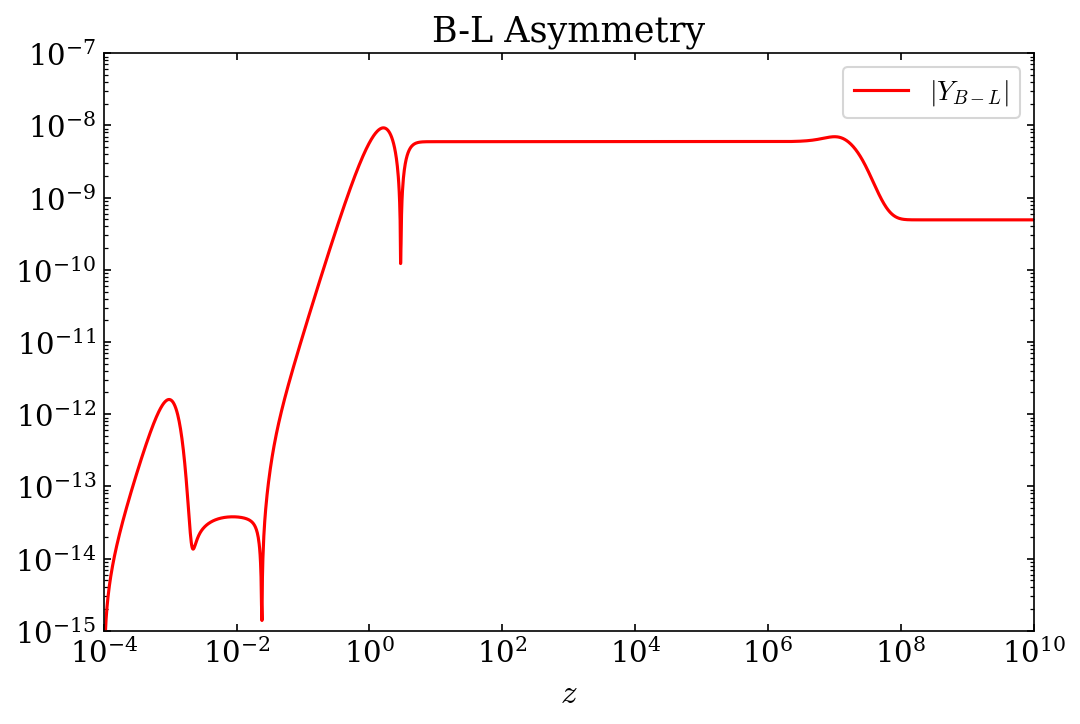

 Plot saved as: Type_I_BL.png


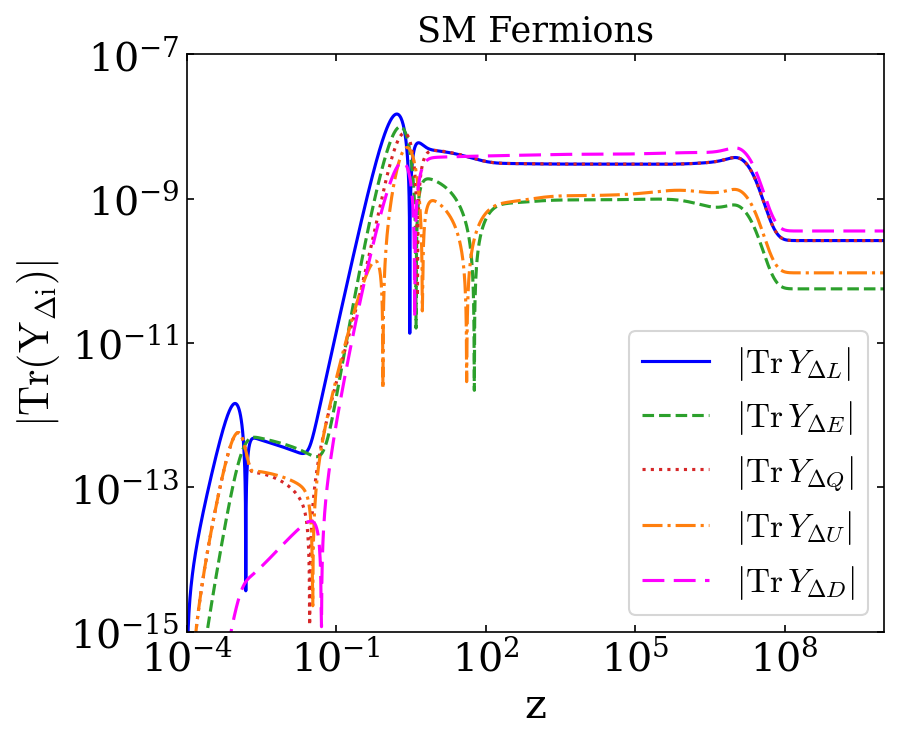

 Plot saved as: Type_I_Ferm.png


In [4]:
EPS_MATS = []
P_MATS = []

for i in range(n):
    y = y1 if i == 0 else y2
    y_dag = y.conj().T
    y_y_dag = y @ y_dag
    y_con = y.conj()
    
    # --- Optimización de epsilonmat(i) ---
    num1 = np.zeros((n, n), dtype=complex)
    num2 = np.zeros((n, n), dtype=complex)
    
    for j in range(n):
        if j != i:
            f_vertex = gfunc(M[j,j]**2 / M[i,i]**2)
            f_self   = M[i,i]**2 / (M[i,i]**2 - M[j,j]**2)
            
            
            term_v = y_y_dag[j,i] * np.outer(y_con[i], y[j]) - y_y_dag[i,j] * np.outer(y_con[j], y[i])
            term_s = y_y_dag[i,j] * np.outer(y_con[i], y[j]) - y_y_dag[j,i] * np.outer(y_con[j], y[i])
            
            num1 += term_v * f_vertex
            num2 += term_s * f_self
            
    den = 16 * np.pi * y_y_dag[i, i]
    EPS_MATS.append((1j * num1 + 1j * num2) / den)
    
    Pi = np.outer(y_con[i], y[i]) / y_y_dag[i,i]
    P_MATS.append(Pi)

EPS_MATS = np.array(EPS_MATS)
P_MATS = np.array(P_MATS)

def W(z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD):

    term_l = YDL * 1 / (bl.gl*bl.Zetal)
    term_h = YDH * 1 / (bl.gH* bl.ZetaH) 
    if hasattr(z, 'free_symbols'):
        WI = sp.zeros(n, n)
    else:
        WI = np.zeros((n, n), dtype=complex)
    
    for i in range(n):
        Pi = P_MATS[i]
        
        gNY_val = gammaNY(z, i) if callable(gammaNY) else gammaNY(z)[i]
        YNeq_val = YNeq(z, i) if callable(YNeq) else YNeq(z)[i]
        
        Wi = gNY_val * YNeq_val / bl.Ynor * (0.5 * (Pi @ term_l + term_l @ Pi) + (Pi @ term_h))
        WI += Wi
        
    return -0.5 * WI  

def SI(z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD):
    YN = y_newphys
    
    if hasattr(z, 'free_symbols'): 
        Si = sp.zeros(n, n)
    else:
        Si = np.zeros((n, n), dtype=complex)
    
    for i in range(n): 
        gNY_val = gammaNY(z, i) if callable(gammaNY) else gammaNY(z)[i]
        YNeq_val = YNeq(z, i) if callable(YNeq) else YNeq(z)[i]
        
        Sis = EPS_MATS[i] * gNY_val * (YN[i] - YNeq_val)     
        Si += Sis     
        
    return Si
def yE_running(z):
    T = Mref/z
    if T<M[0,0]:
        yE_run=yE1
    else:
        yE_run=yE2
    return yE_run
parameters = {
    "yU": yU,
    "yD": yD,
    "yE": yE_running,
}


def dYN(z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD):
    dYN_list = []
    
    for i in range(3):
        gNY_val = gammaNY(z, i) if callable(gammaNY) else gammaNY(z)[i]
        
        
        YNeq_val = YNeq(z, i) if callable(YNeq) else YNeq(z)[i]
        
        
        rhs_i = -gNY_val * (y_newphys[i] - YNeq_val)
        
        dYN_list.append(rhs_i)
        
    return dYN_list
    
dYN.nvars = 3

TypeI_contributions = { 
    "NEW_DEGREES_OF_FREEDOM": [dYN],
    "YDL": [W, SI]
}
funcions_to_protect = ['gammaNY', 'YNeq']


zspan=[1e-4, 1e10]

results = bl.SolveBE(zspan, 
    contributions=TypeI_contributions, 
    params_sm=parameters,
    background_funcs=funcions_to_protect , 
    filename= 'Type_I'
)



# Leptogenesis

--- Analytical Jacobian Matrix ---
--- Lambdify ---
End of Jacobian and Ode
 Complete integration 13.5670 seconds.
✅ Data saved successfully to HDF5: Type_IL.h5
Final B-L Asymmetry
$Y_{B-L}=$ 4.866786161190947e-10


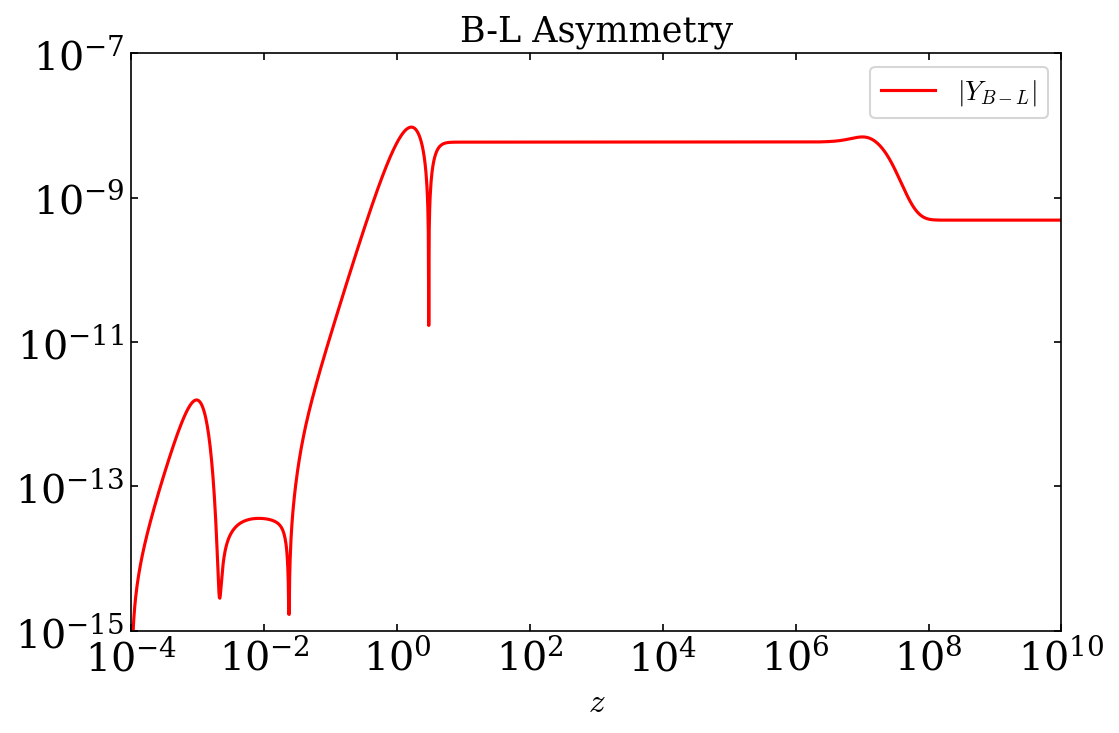

 Plot saved as: Type_IL_BL.png


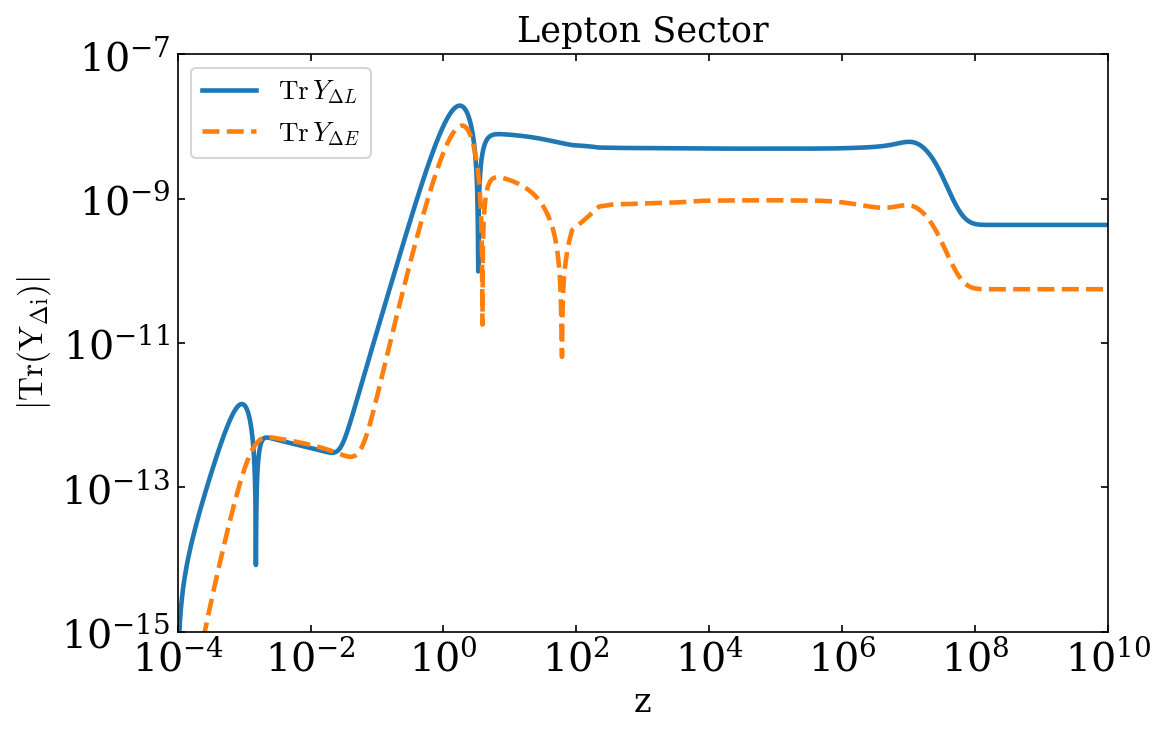

 Plot saved as: Type_IL_Ferm.png


In [5]:
TypeI_contributionsL = { 
    "NEW_DEGREES_OF_FREEDOM": [dYN], 
    #The minus sign
    "YTDelta": [
        lambda z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD, **kwargs: -W(z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD),
        lambda z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD, **kwargs: -SI(z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD)
    ]
}

resultsL = bl.SolveBELE(zspan, 
    contributions=TypeI_contributionsL, 
    params_sm=parameters,
    background_funcs=funcions_to_protect,
    filename= 'Type_IL')


# Comparison

--- LEPTOGENESIS ALONE ---
Final Y_B = 1.5330376407751482e-10
Final eta_B = 1.0791051953416268e-09

--- FULL BARYOGENESIS (WITH QUARKS) ---
Final Y_B = 1.5514015823016538e-10
Final eta_B = 1.092031573782134e-09



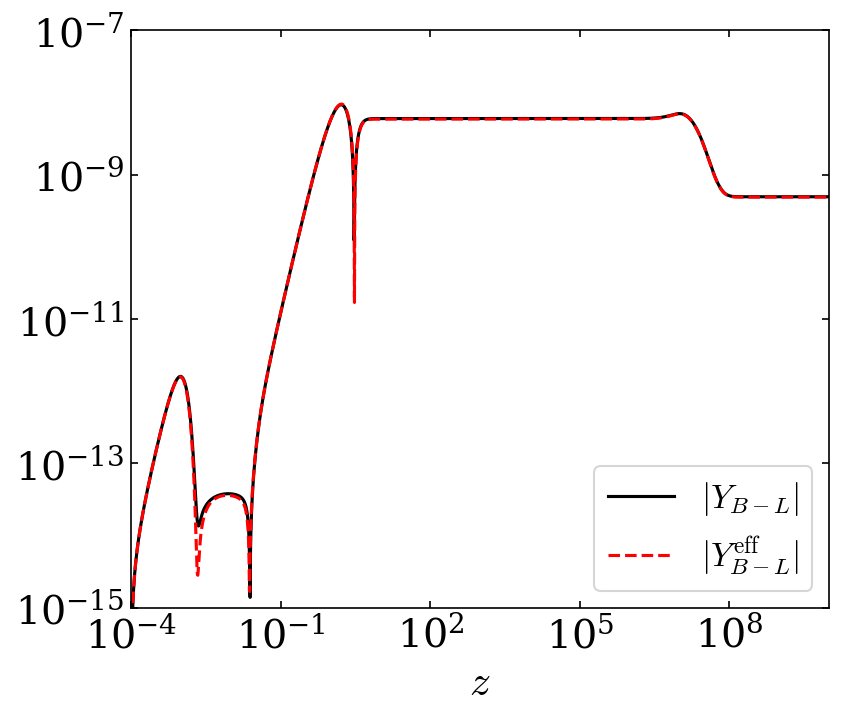

In [6]:

#Lepto Data
z_L = resultsL["z"]
YBL_L = resultsL["YBL"]

YBSM_L = np.abs(0.315 * YBL_L[-1])
etaB_L = 7.039 * YBSM_L
formatted_eta_L = f"{float(etaB_L):.2e}"
mantissa_L, exp_L = formatted_eta_L.split("e")
exp_L = int(exp_L)

print("--- LEPTOGENESIS ALONE ---")
print(f"Final Y_B = {YBSM_L}")
print(f"Final eta_B = {etaB_L}\n")


#Baryo Data
z_B = results["z"]
YBL_B = results["YBL"]


YBSM_B = np.abs(0.315 * YBL_B[-1])
etaB_B = 7.039 * YBSM_B
formatted_eta_B = f"{float(etaB_B):.2e}"
mantissa_B, exp_B = formatted_eta_B.split("e")
exp_B = int(exp_B)

print("--- FULL BARYOGENESIS (WITH QUARKS) ---")
print(f"Final Y_B = {YBSM_B}")
print(f"Final eta_B = {etaB_B}\n")



plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['figure.dpi'] = 150

# 2. Set the uniform font sizes
#plt.rcParams['axes.titlesize'] = 12     # Title font size
#plt.rcParams['axes.titleweight'] = 'bold' # Bold title
plt.rcParams['axes.labelsize'] = 20     # X and Y label font size
plt.rcParams['xtick.labelsize'] = 19    # X axis tick size
plt.rcParams['ytick.labelsize'] = 19   # Y axis tick size
plt.rcParams['legend.fontsize'] = 16
# Curve 2: Full Covariant
plt.plot(
    z_B,
    np.abs(YBL_B),
    label=r'$|Y_{B-L}|$',
    color='black',
    linestyle='-',
    linewidth=1.5
)
# Curve 1: Leptogenesis
plt.plot(
    z_L,
    np.abs(YBL_L),
    label=r'$|Y_{B-L}^{\rm eff}|$',
    color='red',
    linestyle='--',
    linewidth=1.5
)


title = "Comparison BL SSI"
plt.xlim(1e-4, 1e10)  
plt.ylim(1e-15, 1e-7)
plt.xlabel(r'$z$')
#plt.ylabel(r'$|Y_{B-L}|$')  
plt.xscale('log')
plt.yscale('log')
plt.minorticks_on()
plt.tick_params(which='both', top=True, right=True, direction='in')
plt.legend(loc='lower right')  

filename = re.sub(r'[^\w\s-]', '', title)
filename = filename.replace('at', '')
filename = "_".join(filename.split())
filename = filename.strip('_') + ".png"

plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#plt.figure(figsize=(8, 5))

# 1. Set the uniform plot size
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['figure.dpi'] = 150

# 2. Set the uniform font sizes
#plt.rcParams['axes.titlesize'] = 12     # Title font size
#plt.rcParams['axes.titleweight'] = 'bold' # Bold title
plt.rcParams['axes.labelsize'] = 20     # X and Y label font size
plt.rcParams['xtick.labelsize'] = 19    # X axis tick size
plt.rcParams['ytick.labelsize'] = 19   # Y axis tick size
plt.rcParams['legend.fontsize'] = 16
z_B = results["z"]
YDL = results["YDL"]
YDE_B = results["YDE"]
YDQ = results["YDQ"]
YDU = results["YDU"]
YDD = results["YDD"]
YBL = results["YBL"]
y_np = np.asarray(results["y_newphys"])

tr_DL = np.array([np.trace(m) for m in YDL])
tr_DE_B = np.array([np.trace(m) for m in YDE_B])
tr_DQ = np.array([np.trace(m) for m in YDQ])
tr_DU = np.array([np.trace(m) for m in YDU])
tr_DD = np.array([np.trace(m) for m in YDD])
c_H2= -(1/3)*(-tr_DQ -4*tr_DU + 2*tr_DD + 3*tr_DL
               +6*tr_DE_B)/(1/3 *
    (tr_DQ + tr_DU + tr_DD)
  - tr_DL
  - 2*tr_DE_B)

plt.plot(
    z_B,
    np.abs(c_H2),
    label=r'$|c_H|$',
    color='black'
)
plt.plot(z_B,
    np.abs(ch(z_B)),
    label=r'$c_H^{\rm eff}$',
    color='red',
    linestyle ='--')
title="CH SSI"

plt.xlim(1e-4,1e10)
plt.ylim(1e-1,1e0)
plt.xlabel('z')
#plt.ylabel(r'$|c_{H}$')
plt.xscale('log')
#plt.yscale('log')
#plt.title('Normal Ordering')
plt.minorticks_on()
plt.tick_params(which='both', top=True, right=True, direction='in')
plt.legend()
#plt.savefig('Trace.png', dpi=300)

filename = re.sub(r'[^\w\s-]', '', title)   
filename = filename.replace('at', '')       
filename = "_".join(filename.split())       
filename = filename.strip('_') + ".png"     


plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved as: {filename}")

In [ ]:
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['figure.dpi'] = 150

# 2. Set the uniform font sizes
#plt.rcParams['axes.titlesize'] = 12     # Title font size
#plt.rcParams['axes.titleweight'] = 'bold' # Bold title
plt.rcParams['axes.labelsize'] = 20     # X and Y label font size
plt.rcParams['xtick.labelsize'] = 19    # X axis tick size
plt.rcParams['ytick.labelsize'] = 19   # Y axis tick size
plt.rcParams['legend.fontsize'] = 16
#plt.rcParams['font.family'] = 'sans-serif'
#plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'Computer Modern Roman']
#plt.rcParams['mathtext.fontset'] = 'cm' # Computer Modern math style

plt.plot(
    z_B, np.abs(tr_DL),
    lw=1.5, color='blue', ls='-',
    label=r'$|\mathrm{Tr}\,Y_{\Delta L}|$'
)

plt.plot(
    z_B, np.abs(tr_DE_B),
    lw=1.5, color='tab:green', ls='--',
    label=r'$|\mathrm{Tr}\,Y_{\Delta E}|$'
)

plt.plot(
    z_B, np.abs(tr_DQ),
    lw=1.5, color='tab:red', ls=':',
    label=r'$|\mathrm{Tr}\,Y_{\Delta Q}|$'
)

plt.plot(
    z_B, np.abs(tr_DU),
    lw=1.5, color='tab:orange', ls='-.',
    label=r'$|\mathrm{Tr}\,Y_{\Delta U}|$'
)

plt.plot(
    z_B, np.abs(tr_DD),
    lw=1.5, color='magenta', ls=(0, (7, 3)),
    label=r'$|\mathrm{Tr}\,Y_{\Delta D}|$'
)


title = "Ferm SSI"
plt.xlabel(r'$z$')
#plt.ylabel(r'$|\rm{Tr}(Y_{\Delta i})|$')
plt.xlim(1e-4,1e10)
plt.ylim(1e-15,1e-7)
plt.xscale('log')
plt.yscale('log')
plt.minorticks_on()
#plt.title(title)
plt.minorticks_on()
plt.tick_params(which='both', top=True, right=True, direction='in')
plt.legend()

filename = re.sub(r'[^\w\s-]', '', title)   
filename = filename.replace('at', '')       
filename = "_".join(filename.split())       
filename = filename.strip('_') + ".png"    

plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved as: {filename}")

Ulysses baryon asimetry
1.1253263250251552e-10
--- LEPTOGENESIS ALONE ---
Final Y_B = 1.5332087096065584e-10
Final eta_B = 1.0792256106920564e-09

--- FULL BARYOGENESIS (WITH QUARKS) ---
Final Y_B = 1.5514015823016538e-10
Final eta_B = 1.092031573782134e-09



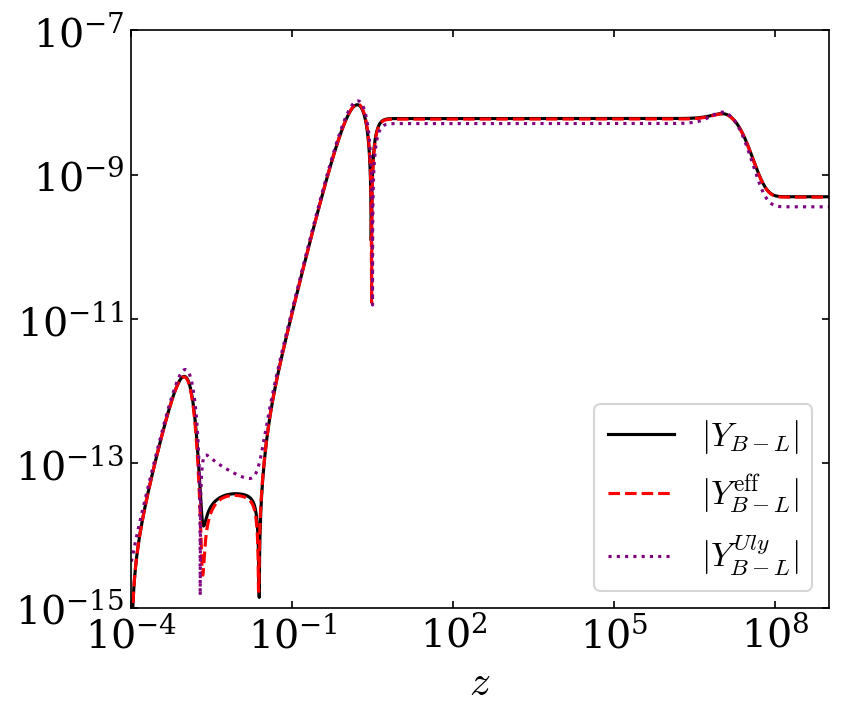

In [10]:
import h5py
with h5py.File("etaB_running_yukawa.h5", "r") as f:
    z_ulysses = f["z"][:]
    N_BL_ulysses = f["N_BL"][:]
    etaB_ulysses = f["etaB"][:]
    
etaB_final_ulysses = etaB_ulysses[-1]
print("Ulysses baryon asimetry")
print(np.abs(etaB_ulysses[-1])/(7.039))
print("====================================================================")


print("--- LEPTOGENESIS ALONE ---")
print(f"Final Y_B = {YBSM_L}")
print(f"Final eta_B = {etaB_L}\n")

print("--- FULL BARYOGENESIS (WITH QUARKS) ---")
print(f"Final Y_B = {YBSM_B}")
print(f"Final eta_B = {etaB_B}\n")
plt.plot(
    z_B,
    np.abs(YBL_B),
    label=r'$|Y_{B-L}|$',
    color='black',
    linestyle='-',
    linewidth=1.5
)
# Curve 1: Leptogenesis
plt.plot(
    z_L,
    np.abs(YBL_L),
    label=r'$|Y_{B-L}^{\rm eff}|$',
    color='red',
    linestyle='--',
    linewidth=1.5
)
plt.plot(
    z_ulysses*1e12/M[0,0],
    np.abs(etaB_ulysses)/(7.039*0.315),
    label=r'$|Y_{B-L}^{Uly}|$',
    color='purple',
    linestyle='dotted',
    linewidth=1.5
)
# Curve 2: Full Covariant


title = "ULYSSES BL SSI"
plt.xlim(1e-4, 1e9)  
plt.ylim(1e-15, 1e-7)
plt.xlabel(r'$z$')
#plt.ylabel(r'$|Y_{B-L}|$')  
plt.xscale('log')
plt.yscale('log')
plt.minorticks_on()
plt.tick_params(which='both', top=True, right=True, direction='in')
plt.legend(loc='lower right')  

filename = re.sub(r'[^\w\s-]', '', title)
filename = filename.replace('at', '')
filename = "_".join(filename.split())
filename = filename.strip('_') + ".png"

plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()